In [5]:
import pandas as pd

# Load the dataset
file_path = 'C:\\Users\\91999\\Downloads\\INFO6090 Assignment 2 - Dataset (1).xlsx'

data = pd.read_excel(file_path)


In [6]:
# Check for duplicates
duplicates = data.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

# Remove duplicates
data = data.drop_duplicates()


Number of duplicate rows: 0


In [8]:
import pandas as pd

# Load your data
file_path = 'C:/Users/91999/Downloads/INFO6090 Assignment 2 - Dataset (1).xlsx'
data = pd.read_excel(file_path)

# Check for duplicates based on specific columns
duplicates = data.duplicated(subset=['Monitoring Date', 'Officer ID', 'Site ID'])

# Display rows with duplicates (if any)
duplicate_rows = data[duplicates]
print("Duplicate Rows based on specified columns:\n", duplicate_rows)

# Optionally, remove these duplicates if desired
data_no_duplicates = data.drop_duplicates(subset=['Monitoring Date', 'Officer ID', 'Site ID'])


Duplicate Rows based on specified columns:
       Monitoring Date  Officer ID   Officer Name Office Location  Site ID  \
643        18-04-2022          18     Beth Smith        Brisbane       21   
891        02-11-2022          18  Catherine Lee          Sydney       14   
1033       20-02-2022           4   Diana Taylor        Brisbane       23   
1192       07-05-2022           9  Catherine Lee       Melbourne       14   
1246       14-07-2022           4     Xena Perez          Hobart       21   
...               ...         ...            ...             ...      ...   
13775      30-07-2022          12   Fiona Wilson        Adelaide       17   
13804      17-07-2022           2    Megan Lewis           Perth       16   
13821      30-12-2022           4   Fiona Wilson          Sydney        5   
13834      05-01-2022           3    Kate Harris           Perth        2   
13840      11-03-2022          14    Laura Clark       Newcastle       12   

                 Site Name     

In [9]:
# Drop duplicates based on specific columns, keeping the first occurrence
data_cleaned = data.drop_duplicates(subset=['Monitoring Date', 'Officer ID', 'Site ID'], keep='first')


In [10]:
# Aggregate duplicates by taking the mean of numeric columns
data_aggregated = data.groupby(['Monitoring Date', 'Officer ID', 'Site ID']).agg({
    'Activity Duration (hours)': 'mean',
    'Pollution Level Detected': 'mean',
    'Community Feedback Rating': 'mean',
    # Add more aggregations as needed for other columns
}).reset_index()


In [11]:
# Add a flag column to indicate duplicates
data['Duplicate_Flag'] = data.duplicated(subset=['Monitoring Date', 'Officer ID', 'Site ID'], keep=False)
# Now you can filter duplicates using `data[data['Duplicate_Flag']]`


In [12]:
# Prioritize rows with "Yes" in key columns when dropping duplicates
data_prioritized = data.sort_values(by=['Compliance Target Achieved', 'Incentive Received'], ascending=False)
data_final = data_prioritized.drop_duplicates(subset=['Monitoring Date', 'Officer ID', 'Site ID'], keep='first')


In [13]:
# Save the final cleaned dataset to a new file
data_final.to_excel('cleaned_data.xlsx', index=False)


In [13]:

# Check for duplicate Transaction IDs
duplicate_transaction_ids = data[data.duplicated(subset=['Transaction ID'], keep=False)]
print("Duplicate Transaction IDs:\n", duplicate_transaction_ids)

# Check for duplicate Activity IDs
duplicate_activity_ids = data[data.duplicated(subset=['Activity ID'], keep=False)]
print("\nDuplicate Activity IDs:\n", duplicate_activity_ids)

# Handling duplicates if necessary

# Option 1: Remove duplicates, keeping the first occurrence
data_unique_transaction = data.drop_duplicates(subset=['Transaction ID'], keep='first')
data_unique_activity = data_unique_transaction.drop_duplicates(subset=['Activity ID'], keep='first')

# Option 2: Flag duplicates without removal for further inspection
data['Duplicate_Transaction_Flag'] = data.duplicated(subset=['Transaction ID'], keep=False)
data['Duplicate_Activity_Flag'] = data.duplicated(subset=['Activity ID'], keep=False)

# Save cleaned dataset if duplicates w


Duplicate Transaction IDs:
       Monitoring Date  Officer ID   Officer Name Office Location  Site ID  \
0          07-01-2022          18      Uma Allen       Newcastle       22   
1          25-08-2022          23    Grace Jones          Sydney       12   
2          11-06-2022           7   Hannah Moore       Melbourne       21   
3          23-09-2022           6   Vicky Turner        Brisbane       21   
4          02-03-2022           1    Laura Clark           Perth       15   
...               ...         ...            ...             ...      ...   
13884      01-01-2022           8     Xena Perez        Adelaide       19   
13885      01-01-2022          15     Ella Brown          Hobart       11   
13886      01-01-2022           6  Alice Johnson          Darwin       13   
13887      01-01-2022          11       Zoe Ward        Canberra        5   
13888      01-01-2022           8  Catherine Lee      Gold Coast        3   

                              Site Name  \
0   

In [14]:

# Remove duplicates in Transaction ID, keeping the first occurrence
data_no_duplicate_transaction = data.drop_duplicates(subset=['Transaction ID'], keep='first')

# Remove duplicates in Activity ID, keeping the first occurrence
# Apply this on the dataset with unique Transaction IDs to ensure both columns are unique
data_no_duplicates = data_no_duplicate_transaction.drop_duplicates(subset=['Activity ID'], keep='first')

# Save the final cleaned dataset to a new file
cleaned_file_path = 'C:/Users/91999/Downloads/cleaned_data_no_duplicates.xlsx'
data_no_duplicates.to_excel(cleaned_file_path, index=False)

print("Duplicate values removed. Cleaned data saved to", cleaned_file_path)


Duplicate values removed. Cleaned data saved to C:/Users/91999/Downloads/cleaned_data_no_duplicates.xlsx


In [15]:
import pandas as pd

# Load the cleaned dataset
file_path = 'C:/Users/91999/Downloads/cleaned_data_no_duplicates.xlsx'
data = pd.read_excel(file_path)

# Get the number of rows and columns
total_rows, total_columns = data.shape

print(f"Total Rows: {total_rows}")
print(f"Total Columns: {total_columns}")


Total Rows: 992
Total Columns: 19


In [16]:

# Check for missing values in each column
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Optionally, display columns with missing values only
missing_values_only = missing_values[missing_values > 0]
print("\nColumns with missing values:\n", missing_values_only)


Missing values in each column:
 Monitoring Date                 0
Officer ID                      0
Officer Name                    0
Office Location                 0
Site ID                         0
Site Name                       0
Site Location                   0
Activity ID                     0
Activity Type                   0
Activity Description            0
Activity Duration (hours)       0
Equipment Used                  0
Pollution Level Detected        0
Compliance Status               0
Community Feedback Rating       0
Transaction ID                  0
Incentive Received              0
Compliance Target Achieved    469
Duplicate_Flag                  0
Duplicate_Transaction_Flag      0
Duplicate_Activity_Flag         0
dtype: int64

Columns with missing values:
 Compliance Target Achieved    469
dtype: int64


In [16]:
import pandas as pd

# Load the dataset
file_path = 'C:/Users/91999/Downloads/cleaned_data_no_duplicates.xlsx'
data = pd.read_excel(file_path)

# Option 3: Drop rows with missing Compliance Status (only if you cannot impute them)
data = data.dropna(subset=['Compliance Status'])

# Save cleaned data if needed
cleaned_file_path = 'C:/Users/91999/Downloads/cleaned_data_final.xlsx'
data.to_excel(cleaned_file_path, index=False)


In [17]:
file_path = 'C:/Users/91999/Downloads/cleaned_data_no_duplicates.xlsx'
data = pd.read_excel(file_path)

# Get the number of rows and columns
total_rows, total_columns = data.shape

print(f"Total Rows: {total_rows}")
print(f"Total Columns: {total_columns}")

Total Rows: 992
Total Columns: 19


In [18]:
# Corrected code with actual column name for office, e.g., 'Office Location'
data['Compliance Rate (%)'] = (data['Compliance Status'] == 'Compliant').astype(int).groupby(data['Office Location']).transform('mean') * 100


In [19]:
import pandas as pd

# Load your data
file_path = 'C:/Users/91999/Downloads/cleaned_data_final.xlsx'
data = pd.read_excel(file_path)

# Calculate Compliance Rate (%) for each office location
data['Compliance Rate (%)'] = data.groupby('Office Location')['Compliance Status'].transform(
    lambda x: (x == 'Compliant').mean() * 100
)


In [29]:
print(data.head())


  Monitoring Date  Officer ID  Officer Name Office Location  Site ID  \
0      07-01-2022          18     Uma Allen       Newcastle       22   
1      25-08-2022          23   Grace Jones          Sydney       12   
2      11-06-2022           7  Hannah Moore       Melbourne       21   
3      23-09-2022           6  Vicky Turner        Brisbane       21   
4      02-03-2022           1   Laura Clark           Perth       15   

               Site Name                           Site Location  Activity ID  \
0  Warners Bay Foreshore    Wharf Road, Newcastle East, NSW 2300          730   
1       King Edward Park       Darling Harbour, Sydney, NSW 2000          147   
2        Newcastle Beach  Federation Square, Melbourne, VIC 3000          259   
3       Merewether Beach   Queen Street Mall, Brisbane, QLD 4000          224   
4           Nobbys Beach         Cottesloe Beach, Perth, WA 6011          821   

             Activity Type Activity Description  ...  \
0  Noise Level Measureme

In [20]:
# Save the updated DataFrame to a new file to ensure all changes are included
output_path = 'C:/Users/91999/Downloads/updated_data_with_compliance_rate.xlsx'
data.to_excel(output_path, index=False)

print("Updated data saved to:", output_path)


Updated data saved to: C:/Users/91999/Downloads/updated_data_with_compliance_rate.xlsx


In [21]:
# Example assuming columns for personnel hours and equipment count
data['Total Resources Used'] = data['Activity Duration (hours)'] + data['Equipment Used'].apply(lambda x: len(x.split(',')))


In [22]:
# Calculate the difference in community feedback rating between current and previous record for each office
data['Feedback Change'] = data.groupby('Office Location')['Community Feedback Rating'].diff()


In [23]:
# Example calculation, normalize each metric and sum for an efficiency score
data['Efficiency Score'] = (data['Compliance Rate (%)'] / data['Compliance Rate (%)'].max() +
                            data['Community Feedback Rating'] / data['Community Feedback Rating'].max() +
                            (1 - data['Total Resources Used'] / data['Total Resources Used'].max()))


In [24]:
import pandas as pd

# Specify the path where you want to save the updated DataFrame
output_file_path = 'C:/Users/91999/Downloads/updated_data_with_compliance_rate1.xlsx'

# Save the DataFrame to an Excel file
data.to_excel(output_file_path, index=False)  # index=False excludes the index column in the Excel file

print(f"Data saved successfully to {output_file_path}")


Data saved successfully to C:/Users/91999/Downloads/updated_data_with_compliance_rate1.xlsx


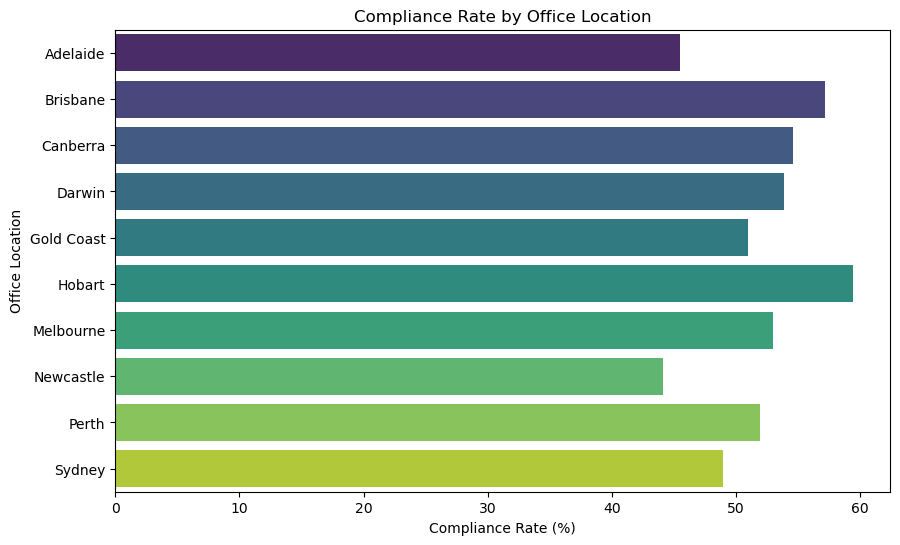

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' is your cleaned DataFrame
# Calculate compliance rate by office location
compliance_rate = data.groupby('Office Location')['Compliance Status'].apply(lambda x: (x == 'Compliant').mean() * 100).reset_index()
compliance_rate.columns = ['Office Location', 'Compliance Rate (%)']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=compliance_rate, x='Compliance Rate (%)', y='Office Location', palette="viridis")
plt.title('Compliance Rate by Office Location')
plt.xlabel('Compliance Rate (%)')
plt.ylabel('Office Location')
plt.show()


<Figure size 1000x600 with 0 Axes>

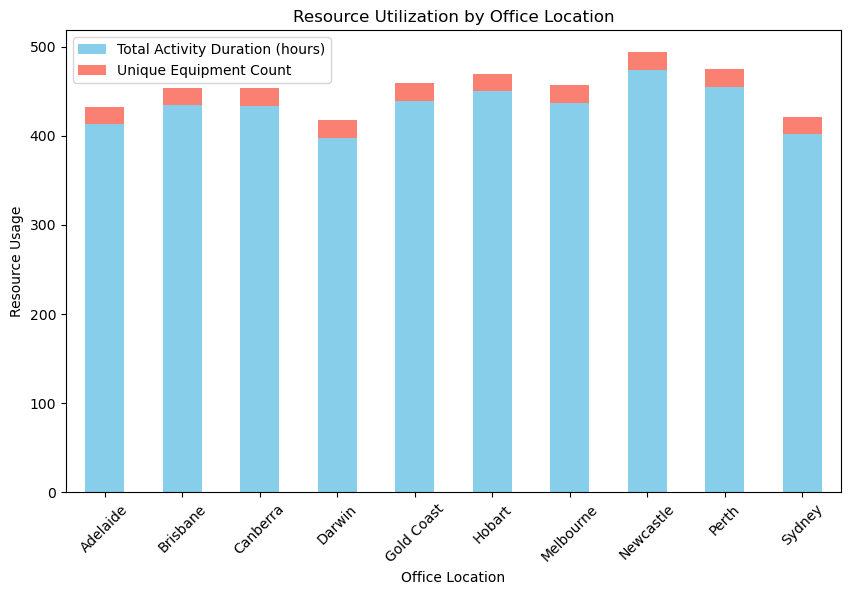

In [40]:
# Calculate total resource usage by office
resource_usage = data.groupby('Office Location').agg({
    'Activity Duration (hours)': 'sum',
    'Equipment Used': 'nunique'
}).reset_index()
resource_usage.columns = ['Office Location', 'Total Activity Duration (hours)', 'Unique Equipment Count']

# Plot
plt.figure(figsize=(10, 6))
resource_usage.set_index('Office Location').plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Resource Utilization by Office Location')
plt.xlabel('Office Location')
plt.ylabel('Resource Usage')
plt.legend(['Total Activity Duration (hours)', 'Unique Equipment Count'])
plt.xticks(rotation=45)
plt.show()


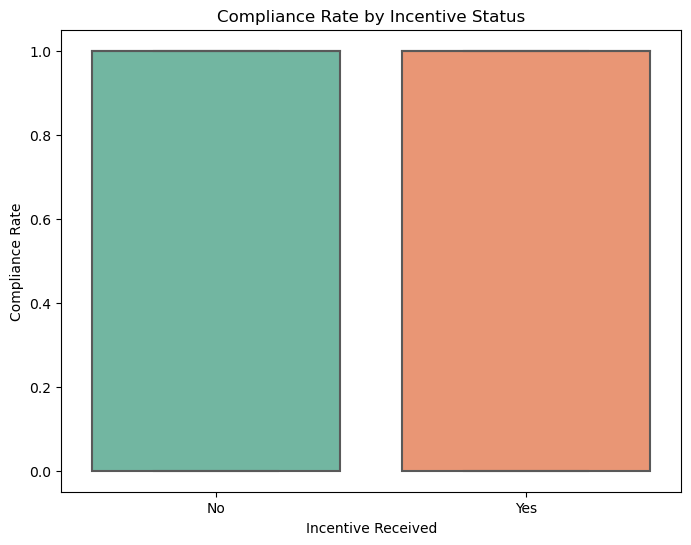

In [41]:
# Add a binary compliance column for easier plotting
data['Compliant'] = (data['Compliance Status'] == 'Compliant').astype(int)

# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x='Incentive Received', y='Compliant', palette="Set2")
plt.title('Compliance Rate by Incentive Status')
plt.xlabel('Incentive Received')
plt.ylabel('Compliance Rate')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


In [25]:
import pandas as pd

# Assuming 'data' is your DataFrame and it contains 'Incentive Received' and 'Compliance Status' columns

# Define Incentive Impact Score: 1 if Incentive Received is 'Yes' and Compliance Status is 'Compliant', otherwise 0
data['Incentive Impact Score'] = ((data['Incentive Received'] == 'Yes') & (data['Compliance Status'] == 'Compliant')).astype(int)

# Display the first few rows to verify
print(data[['Incentive Received', 'Compliance Status', 'Incentive Impact Score']].head())


  Incentive Received Compliance Status  Incentive Impact Score
0                Yes         Compliant                       1
1                Yes         Compliant                       1
2                Yes     Non-Compliant                       0
3                 No         Compliant                       0
4                Yes         Compliant                       1


In [26]:
# Save the updated DataFrame to a new file to ensure all changes are included
output_path = 'C:/Users/91999/Downloads/updated_data_with_compliance_rate5.xlsx'
data.to_excel(output_path, index=False)

print("Updated data saved to:", output_path)


Updated data saved to: C:/Users/91999/Downloads/updated_data_with_compliance_rate5.xlsx
